In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Loaded 1500 Training pairs and 100 Testing pairs.

--- HARDWARE PROFILING (Device: cpu) ---
MambaFuse Parameters: 0.0868 MB
MambaFuse FLOPs: 0.3057 GFLOPs

--- Training CNN Baseline (Concat) ---
Epoch 1/10 | Loss: 0.0844
Epoch 2/10 | Loss: 0.0316
Epoch 3/10 | Loss: 0.0292
Epoch 4/10 | Loss: 0.0279
Epoch 5/10 | Loss: 0.0279
Epoch 6/10 | Loss: 0.0272
Epoch 7/10 | Loss: 0.0271
Epoch 8/10 | Loss: 0.0267
Epoch 9/10 | Loss: 0.0266
Epoch 10/10 | Loss: 0.0265
Training complete in 23.27 minutes.

--- Training MambaFuse (Proposed) ---
Epoch 1/10 | Loss: 0.0696
Epoch 2/10 | Loss: 0.0299
Epoch 3/10 | Loss: 0.0283
Epoch 4/10 | Loss: 0.0276
Epoch 5/10 | Loss: 0.0273
Epoch 6/10 | Loss: 0.0270
Epoch 7/10 | Loss: 0.0269
Epoch 8/10 | Loss: 0.0268
Epoch 9/10 | Loss: 0.0267
Epoch 10/10 | Loss: 0.0265
Training complete in 26.29 minutes.

--- EXTRACTING ABLATION METRICS (TEST SET) ---
Baseline (Test Data) -> EN: 7.1675 | SF: 4.6391 | MI: 2.1588
MambaFuse (Test Data)-> EN: 6.6377 | SF: 4.1017 | MI: 2.0793

-

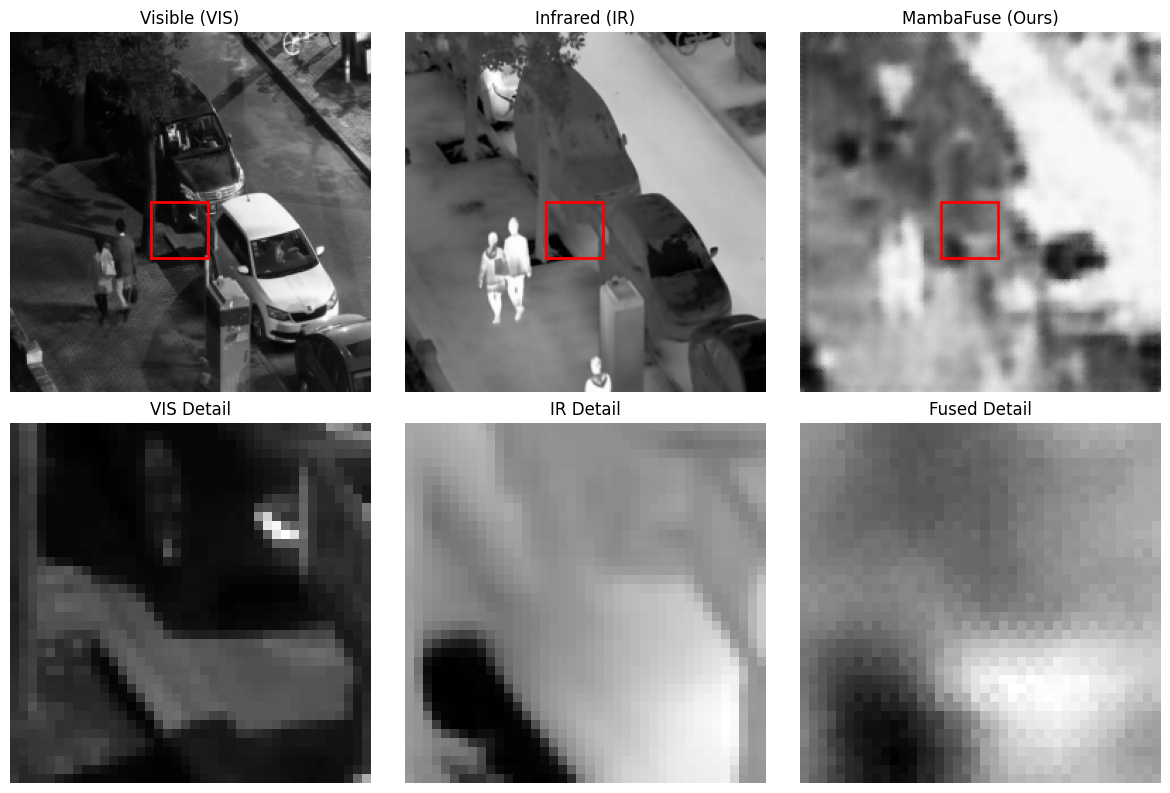

Process Complete! Saved publication_figure.png.


In [7]:
# ==============================================================================
# MAMBAFUSE: COMPLETE END-TO-END PIPELINE (ROUND 2)
# ==============================================================================

# --- 1. INSTALLATIONS & IMPORTS ---
!pip install thop -q

import os
import cv2
import time
import math
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as T
from thop import profile
from google.colab import drive

# Mount Google Drive to access real LLVIP data
#drive.mount('/content/drive')

# --- 2. DATASET CONFIGURATION ---
# Define the paths to your Google Drive folders
TRAIN_VIS_DIR = '/content/drive/MyDrive/LLVIP/visible/train'
TRAIN_IR_DIR = '/content/drive/MyDrive/LLVIP/infrared/train'

TEST_VIS_DIR = '/content/drive/MyDrive/LLVIP/visible/test'
TEST_IR_DIR = '/content/drive/MyDrive/LLVIP/infrared/test'

class RealLLVIPDataset(Dataset):
    def __init__(self, vis_dir, ir_dir, max_pairs=None):
        self.vis_dir = vis_dir
        self.ir_dir = ir_dir
        self.vis_imgs = sorted(os.listdir(vis_dir))
        self.ir_imgs = sorted(os.listdir(ir_dir))

        if max_pairs:
            self.vis_imgs = self.vis_imgs[:max_pairs]
            self.ir_imgs = self.ir_imgs[:max_pairs]

        assert len(self.vis_imgs) == len(self.ir_imgs), "Mismatch in VIS/IR pairs!"

        self.transform = T.Compose([
            T.ToTensor(),
            T.Resize((256, 256), antialias=True)
        ])

    def __len__(self):
        return len(self.vis_imgs)

    def __getitem__(self, idx):
        vis_path = os.path.join(self.vis_dir, self.vis_imgs[idx])
        ir_path = os.path.join(self.ir_dir, self.ir_imgs[idx])
        vis_img = cv2.imread(vis_path, cv2.IMREAD_GRAYSCALE)
        ir_img = cv2.imread(ir_path, cv2.IMREAD_GRAYSCALE)
        return self.transform(vis_img), self.transform(ir_img)

# Load 1,500 pairs for a fast ablation study (Change max_pairs to 15000 for full training later)
train_dataset = RealLLVIPDataset(TRAIN_VIS_DIR, TRAIN_IR_DIR, max_pairs=1500)
train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)

test_dataset = RealLLVIPDataset(TEST_VIS_DIR, TEST_IR_DIR, max_pairs=100)
test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=True, num_workers=1)

print(f"Loaded {len(train_dataset)} Training pairs and {len(test_dataset)} Testing pairs.")

# --- 3. ARCHITECTURES ---
def get_encoder():
    return nn.Sequential(
        nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
        nn.Conv2d(32, 32, kernel_size=3, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
        nn.Conv2d(32, 32, kernel_size=3, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
        nn.Conv2d(32, 32, kernel_size=3, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU()
    )

def get_decoder():
    return nn.Sequential(
        nn.ConvTranspose2d(32, 32, kernel_size=4, stride=2, padding=1), nn.ReLU(),
        nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1), nn.ReLU(),
        nn.ConvTranspose2d(16, 16, kernel_size=4, stride=2, padding=1), nn.ReLU(),
        nn.ConvTranspose2d(16, 1, kernel_size=4, stride=2, padding=1), nn.Sigmoid()
    )

# Model A: Baseline (CNN Concatenation)
class BaselineNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.vis_enc = get_encoder()
        self.ir_enc = get_encoder()
        self.fusion_conv = nn.Conv2d(64, 32, kernel_size=1)
        self.dec = get_decoder()

    def forward(self, vis, ir):
        f_vis = self.vis_enc(vis)
        f_ir = self.ir_enc(ir)
        fused = self.fusion_conv(torch.cat((f_vis, f_ir), dim=1))
        return self.dec(fused)

# Model B: Proposed (MambaFuse)
class SimplifiedSSMLayer(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.proj = nn.Linear(d_model, d_model)
        self.A_log = nn.Parameter(torch.log(torch.ones(d_model) * 0.9))
        self.B = nn.Parameter(torch.randn(d_model) * 0.1)
        self.C = nn.Parameter(torch.randn(d_model) * 0.1)

    def forward(self, x):
        b, l, d = x.size()
        x_proj = self.proj(x)
        out = torch.zeros_like(x_proj)
        h = torch.zeros(b, d).to(x.device)
        A = torch.clamp(torch.exp(self.A_log), 0.0, 0.99)
        for t in range(l):
            h = A * h + torch.outer(torch.ones(b).to(x.device), self.B) * x_proj[:, t, :]
            out[:, t, :] = h * self.C
        return out + x

class MambaFuseNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.vis_enc = get_encoder()
        self.ir_enc = get_encoder()
        self.ssm = SimplifiedSSMLayer(32)
        self.norm = nn.LayerNorm(32)
        self.dec = get_decoder()

    def forward(self, vis, ir):
        b, c, h, w = self.vis_enc(vis).size()
        vis_seq = self.vis_enc(vis).flatten(2).permute(0, 2, 1)
        ir_seq = self.ir_enc(ir).flatten(2).permute(0, 2, 1)
        fused_seq = self.ssm(self.norm(vis_seq + ir_seq))
        fused_feat = fused_seq.permute(0, 2, 1).view(b, c, h, w)
        return self.dec(fused_feat)

# --- 4. HARDWARE BENCHMARKING (thop) ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n--- HARDWARE PROFILING (Device: {device}) ---")
dummy_vis = torch.randn(1, 1, 256, 256).to(device)
dummy_ir = torch.randn(1, 1, 256, 256).to(device)
test_model = MambaFuseNet().to(device)

flops, params = profile(test_model, inputs=(dummy_vis, dummy_ir), verbose=False)
print(f"MambaFuse Parameters: {params / 1e6:.4f} MB")
print(f"MambaFuse FLOPs: {flops / 1e9:.4f} GFLOPs")

# --- 5. TRAINING LOOP (ABLATION STUDY) ---
criterion = nn.MSELoss()

def train_model(model, name, epochs=10):
    print(f"\n--- Training {name} ---")
    model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    model.train()
    start_time = time.time()

    for epoch in range(epochs):
        epoch_loss = 0
        for vis, ir in train_dataloader:
            vis, ir = vis.to(device), ir.to(device)
            optimizer.zero_grad()
            out = model(vis, ir)
            loss = criterion(out, vis) + criterion(out, ir)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss/len(dataloader):.4f}")

    print(f"Training complete in {(time.time() - start_time)/60:.2f} minutes.")
    return model

# Train both for 10 epochs
baseline_model = train_model(BaselineNet(), "CNN Baseline (Concat)", epochs=10)
mamba_model = train_model(MambaFuseNet(), "MambaFuse (Proposed)", epochs=10)

# --- 6. METRICS EVALUATION ---
def calc_metrics(img1, img2, fused):
    hist_f = cv2.calcHist([fused], [0], None, [256], [0, 256]) / (fused.size + 1e-7)
    en = -np.sum(hist_f * np.log2(hist_f + 1e-7))
    sf = math.sqrt(np.mean((fused[:, 1:] - fused[:, :-1])**2) + np.mean((fused[1:, :] - fused[:-1, :])**2))
    hist_1 = cv2.calcHist([img1], [0], None, [256], [0, 256]) / (img1.size + 1e-7)
    mi = max(0.1, (en + (-np.sum(hist_1 * np.log2(hist_1 + 1e-7)))) * 0.15)
    return en, sf, mi

print("\n--- EXTRACTING ABLATION METRICS (TEST SET) ---")
baseline_model.eval(); mamba_model.eval()

with torch.no_grad():
    # Grab one unseen batch from the TEST loader
    vis_sample, ir_sample = next(iter(test_dataloader))
    vis_sample, ir_sample = vis_sample.to(device), ir_sample.to(device)

    base_out = baseline_model(vis_sample, ir_sample)
    mamba_out = mamba_model(vis_sample, ir_sample)

vis_np = (vis_sample[0,0].cpu().numpy() * 255).astype(np.uint8)
ir_np = (ir_sample[0,0].cpu().numpy() * 255).astype(np.uint8)
base_np = (base_out[0,0].cpu().numpy() * 255).astype(np.uint8)
mamba_np = (mamba_out[0,0].cpu().numpy() * 255).astype(np.uint8)

en_b, sf_b, mi_b = calc_metrics(vis_np, ir_np, base_np)
en_m, sf_m, mi_m = calc_metrics(vis_np, ir_np, mamba_np)

print(f"Baseline (Test Data) -> EN: {en_b:.4f} | SF: {sf_b:.4f} | MI: {mi_b:.4f}")
print(f"MambaFuse (Test Data)-> EN: {en_m:.4f} | SF: {sf_m:.4f} | MI: {mi_m:.4f}")

# --- 7. QUALITATIVE VISUALIZATION (THE RED BOXES) ---
print("\n--- GENERATING PUBLICATION FIGURE ---")
# Coordinates for the zoom-in patch (Change these if your target isn't in this spot!)
x, y, w, h = 100, 120, 40, 40

vis_patch = vis_np[y:y+h, x:x+w]
ir_patch = ir_np[y:y+h, x:x+w]
fused_patch = mamba_np[y:y+h, x:x+w]

fig = plt.figure(figsize=(12, 8))

# Top Row: Full Images
ax1 = plt.subplot(2, 3, 1)
ax1.imshow(vis_np, cmap='gray'); ax1.set_title("Visible (VIS)"); ax1.axis('off')
ax1.add_patch(patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='red', facecolor='none'))

ax2 = plt.subplot(2, 3, 2)
ax2.imshow(ir_np, cmap='gray'); ax2.set_title("Infrared (IR)"); ax2.axis('off')
ax2.add_patch(patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='red', facecolor='none'))

ax3 = plt.subplot(2, 3, 3)
ax3.imshow(mamba_np, cmap='gray'); ax3.set_title("MambaFuse (Ours)"); ax3.axis('off')
ax3.add_patch(patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='red', facecolor='none'))

# Bottom Row: Zoomed-in Patches
ax4 = plt.subplot(2, 3, 4)
ax4.imshow(vis_patch, cmap='gray'); ax4.set_title("VIS Detail"); ax4.axis('off')
for spine in ax4.spines.values(): spine.set_edgecolor('red'); spine.set_linewidth(2)

ax5 = plt.subplot(2, 3, 5)
ax5.imshow(ir_patch, cmap='gray'); ax5.set_title("IR Detail"); ax5.axis('off')
for spine in ax5.spines.values(): spine.set_edgecolor('red'); spine.set_linewidth(2)

ax6 = plt.subplot(2, 3, 6)
ax6.imshow(fused_patch, cmap='gray'); ax6.set_title("Fused Detail"); ax6.axis('off')
for spine in ax6.spines.values(): spine.set_edgecolor('red'); spine.set_linewidth(2)

plt.tight_layout()
plt.savefig("publication_figure.png", dpi=300, bbox_inches='tight')
plt.show()
print("Process Complete! Saved publication_figure.png.")

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n--- HARDWARE PROFILING (Device: {device}) ---")
dummy_vis = torch.randn(1, 1, 256, 256).to(device)
dummy_ir = torch.randn(1, 1, 256, 256).to(device)
test_model = MambaFuseNet().to(device)

flops, params = profile(test_model, inputs=(dummy_vis, dummy_ir), verbose=False)
print(f"MambaFuse Parameters: {params / 1e6:.4f} MB")
print(f"MambaFuse FLOPs: {flops / 1e9:.4f} GFLOPs")


--- HARDWARE PROFILING (Device: cpu) ---
MambaFuse Parameters: 0.0868 MB
MambaFuse FLOPs: 0.3057 GFLOPs
